# 08_FusionEval_Val1

Val1(이상, label=1) trial에 대해 노이즈 이미지 기준 융합 모델 성능 평가.

```
final_prob = W_IMG × p_img + W_SENSOR × p_sensor
noise_level = clip(ae_error / AE_ERROR_MAX, 0, 1)
W_IMG = 1 - noise_level  / W_SENSOR = noise_level
```

- 노이즈 종류별(full_mixed / fume_smoke / vibration) 분리 평가
- 이미지 단독(MobileNetV2) / 센서 단독(RNN) / 융합 3-way 비교
- 지표: Recall / Accuracy / Weighted F1 / Macro F1

In [19]:
from pathlib import Path
import torch

BASE_DIR       = Path.home() / 'Desktop' / 'ai1' / 'noise_target'
NOISE_PIC_DIR  = BASE_DIR / 'noise_pic' / 'noise_selected'
SENSOR_DIR     = BASE_DIR / 'original_INC_202501'
MOBILENET_PATH = BASE_DIR / 'best_mobilenet.pth'
RNN_PATH       = BASE_DIR / 'best_rnn.pt'
AUTOENC_PATH   = BASE_DIR / 'autoencoder_split_rgb.pth'

TARGET_TRIAL  = 'Val1'
TARGET_LABEL  = 1

FEATURES      = ['Avg Voltage', 'Avg Current']
WINDOW_SIZE   = 30
SENSOR_HZ     = 10
VAL_TRIAL_IDS = {44, 45}
AE_IMG_SIZE   = 256
LATENT_DIM    = 512
MOBILENET_SIZE = 224
THRESHOLD     = 0.5
RANDOM_SEED   = 42

REF_IMG_PATH = (NOISE_PIC_DIR / 'Val8_237A_22TS_200WFR' / 'full_mixed'
                / 'label0_Val8_237A_22TS_200WFR_t0.52s_full_mixed.png')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'평가 대상: {TARGET_TRIAL} (label={TARGET_LABEL})')

Device: cuda
평가 대상: Val1 (label=1)


In [20]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

NOISE_TYPES = ['vibration']
print(f'노이즈 종류: {NOISE_TYPES}')

노이즈 종류: ['vibration']


In [21]:
# ── MobileNetV2 ───────────────────────────────────────────────────
mobilenet = models.mobilenet_v2(weights=None)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, 2)
mobilenet.load_state_dict(
    torch.load(str(MOBILENET_PATH), map_location=DEVICE, weights_only=True))
mobilenet = mobilenet.to(DEVICE).eval()

mn_tf = transforms.Compose([
    transforms.Resize((MOBILENET_SIZE, MOBILENET_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

@torch.no_grad()
def predict_image(img_path):
    img = mn_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    return float(torch.softmax(mobilenet(img), dim=1)[0, 1].cpu())

print(f'MobileNetV2 로드 완료')

# ── RNN ───────────────────────────────────────────────────────────
class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_features, hidden1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(hidden1, hidden2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden2, 1)
    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:,-1,:]))).squeeze(-1)

rnn_model = RNNAnomalyDetector(4, 32, 16, 0.5).to(DEVICE)
rnn_model.load_state_dict(
    torch.load(str(RNN_PATH), map_location=DEVICE, weights_only=True))
rnn_model.eval()

@torch.no_grad()
def predict_sensor(win_np):
    x = torch.from_numpy(win_np.astype(np.float32)).unsqueeze(0).to(DEVICE)
    return float(rnn_model(x).cpu())

print(f'RNN 로드 완료')

# ── Autoencoder ───────────────────────────────────────────────────
class Encoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32,  4,2,1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Conv2d(32,  64,  4,2,1),          nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Conv2d(64,  128, 4,2,1),          nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 4,2,1),          nn.BatchNorm2d(256), nn.ReLU(),
        )
        self._fs = self.net(torch.zeros(1, in_channels, AE_IMG_SIZE, AE_IMG_SIZE)).view(1,-1).shape[1]
        self.fc  = nn.Linear(self._fs, latent_dim)
    def forward(self, x):
        return self.fc(self.net(x).view(x.size(0), -1))

class Decoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512, flatten_size=None, spatial=16):
        super().__init__()
        self.spatial = spatial
        self.fc  = nn.Linear(latent_dim, flatten_size)
        self.net = nn.Sequential(
            nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False),
            nn.Conv2d(256,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False),
            nn.Conv2d(128,64, 3,padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False),
            nn.Conv2d(64, 32, 3,padding=1), nn.BatchNorm2d(32),  nn.ReLU(),
            nn.Upsample(scale_factor=2,mode='bilinear',align_corners=False),
            nn.Conv2d(32, in_channels, 3, padding=1), nn.Tanh(),
        )
    def forward(self, z):
        return self.net(self.fc(z).view(z.size(0), 256, self.spatial, self.spatial))

class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        fs = self.encoder._fs
        self.decoder = Decoder(in_channels, latent_dim, fs, int((fs/256)**0.5))
    def forward(self, x):
        return self.decoder(self.encoder(x))

ckpt = torch.load(str(AUTOENC_PATH), map_location=DEVICE, weights_only=False)
ae   = Autoencoder(3, LATENT_DIM).to(DEVICE)
ae.load_state_dict(ckpt['model_state_dict'])
ae.eval()

ae_tf = transforms.Compose([
    transforms.Resize((AE_IMG_SIZE, AE_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

@torch.no_grad()
def recon_error(img_path):
    img = ae_tf(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    return float(((ae(img) - img)**2).mean().cpu())

# AE_ERROR_MAX: 기준 노이즈 이미지 복원 오차
ref_img     = ae_tf(Image.open(REF_IMG_PATH).convert('RGB')).unsqueeze(0).to(DEVICE)
AE_ERROR_MAX = float(((ae(ref_img) - ref_img)**2).mean().cpu())
print(f'Autoencoder 로드 완료  AE_ERROR_MAX={AE_ERROR_MAX:.6f}')

MobileNetV2 로드 완료
RNN 로드 완료
Autoencoder 로드 완료  AE_ERROR_MAX=0.038352


In [22]:
# 센서 데이터 로드 + 글로벌 StandardScaler
def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    return (float(m.group(1)), float(m.group(2))) if m else (None, None)

sensor_raw  = {}
train_arrs  = []

for d in sorted(SENSOR_DIR.iterdir()):
    if not d.is_dir(): continue
    m = re.match(r'^(Test|Val)(\d+)_', d.name, re.IGNORECASE)
    if not m: continue
    ptype, idx = m.group(1).capitalize(), int(m.group(2))
    short = f'{ptype}{idx}'
    ts, wfr = parse_meta(d.name)
    if ts is None: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    vi = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mn, sd = vi.mean(0), vi.std(0); sd[sd < 1e-8] = 1e-8
    vi_z = (vi - mn) / sd
    arr  = np.hstack([vi_z,
                      np.full((len(vi_z), 1), ts),
                      np.full((len(vi_z), 1), wfr)]).astype(np.float32)
    sensor_raw[short] = arr
    if ptype == 'Test' and idx not in VAL_TRIAL_IDS:
        train_arrs.append(arr)

scaler       = StandardScaler().fit(np.vstack(train_arrs).reshape(-1, 4))
sensor_scaled = {k: scaler.transform(v).astype(np.float32)
                 for k, v in sensor_raw.items()}

def get_sensor_window(trial, time_sec):
    arr = sensor_scaled.get(trial)
    if arr is None: return None
    idx = min(int(round(time_sec * SENSOR_HZ)), len(arr) - 1)
    if idx < WINDOW_SIZE - 1: return None
    return arr[idx - WINDOW_SIZE + 1 : idx + 1]

print(f'센서 로드 완료: {len(sensor_scaled)}개 trial')
print(f'{TARGET_TRIAL} 센서 길이: {len(sensor_scaled.get(TARGET_TRIAL, []))} 샘플')

센서 로드 완료: 19개 trial
Val1 센서 길이: 265 샘플


In [23]:
# 노이즈 이미지 파싱 함수
def parse_noise_image(img_path):
    stem       = img_path.stem
    trial_full = img_path.parent.parent.name
    mp = re.match(r'^((?:Test|Val))(\d+)', trial_full, re.IGNORECASE)
    if not mp: return None
    trial_prefix = mp.group(1).capitalize() + mp.group(2)
    ml = re.match(r'^label(\d+)_', stem)
    if not ml: return None
    label = int(ml.group(1))
    mt = re.search(r'_t(\d+\.?\d*)s_', stem)
    if not mt: return None
    return trial_prefix, float(mt.group(1)), label

def get_weights(err):
    nl = float(np.clip(err / AE_ERROR_MAX, 0.0, 1.0))
    return 1.0 - nl, nl   # w_img, w_sensor

print('파싱 함수 정의 완료')

파싱 함수 정의 완료


In [24]:
# Val1 vibration 노이즈 이미지 융합 추론
results = {}

val1_dir = next((d for d in NOISE_PIC_DIR.iterdir()
                 if d.is_dir() and d.name.upper().startswith('VAL1')), None)
if val1_dir is None:
    raise FileNotFoundError(f'{TARGET_TRIAL} 폴더를 찾을 수 없습니다: {NOISE_PIC_DIR}')
print(f'Val1 폴더: {val1_dir.name}')

for noise_type in NOISE_TYPES:
    img_paths = sorted(val1_dir.glob(f'{noise_type}/*.png'))
    rows = []
    skipped = 0

    for img_path in img_paths:
        info = parse_noise_image(img_path)
        if info is None: continue
        trial_prefix, time_sec, label = info
        if label not in (0, 1):
            skipped += 1; continue

        win = get_sensor_window(trial_prefix, time_sec)
        if win is None:
            skipped += 1; continue

        err      = recon_error(img_path)
        p_sensor = predict_sensor(win)
        w_i, w_s = get_weights(err)
        p_img    = predict_image(img_path)
        p_final  = w_i * p_img + w_s * p_sensor

        rows.append({
            'time_sec':    time_sec,
            'label':       label,
            'ae_error':    round(err,      6),
            'w_img':       round(w_i,      4),
            'w_sensor':    round(w_s,      4),
            'p_sensor':    round(p_sensor, 4),
            'p_final':     round(p_final,  4),
            'pred_sensor': int(p_sensor >= THRESHOLD),
            'pred_fusion': int(p_final  >= THRESHOLD),
        })

    df = pd.DataFrame(rows).sort_values('time_sec').reset_index(drop=True)
    results[noise_type] = df
    print(f'[{noise_type}]  처리={len(df)}장  스킵={skipped}장  label={TARGET_LABEL}')
    print(f'  recall_fusion ={(df["pred_fusion"]==1).mean():.3f}  '
          f'recall_sensor={(df["pred_sensor"]==1).mean():.3f}')

print('\n추론 완료')

Val1 폴더: Val1_130A_22TS_170WFR
[vibration]  처리=227장  스킵=45장  label=1
  recall_fusion =0.648  recall_sensor=0.000

추론 완료


In [25]:
# 평가 — 센서 단독(RNN) / 융합 비교
summary = []
for nt in NOISE_TYPES:
    df = results[nt]
    if len(df) == 0: continue
    y = df['label'].values

    row = {'noise_type': nt, 'n': len(df),
           'w_img_mean':  round(df['w_img'].mean(),  4),
           'w_sen_mean':  round(df['w_sensor'].mean(),4),
           'ae_err_mean': round(df['ae_error'].mean(),6)}

    print(f'\n{"="*60}')
    print(f'  [{nt}]  n={len(df)}  (전부 label=1 이상)')
    print(f'  AE오차={df["ae_error"].mean():.4f}  '
          f'W_IMG={df["w_img"].mean():.3f}  W_SEN={df["w_sensor"].mean():.3f}')
    print(f'{"="*60}')

    for key, col in [('센서 단독(RNN)', 'pred_sensor'),
                     ('융합',           'pred_fusion')]:
        yp  = df[col].values
        rec = recall_score(y, yp, labels=[0,1], pos_label=1, zero_division=0)
        wf1 = f1_score(y, yp, labels=[0,1], average='weighted', zero_division=0)
        mf1 = f1_score(y, yp, labels=[0,1], average='macro',    zero_division=0)
        print(f'  [{key:14s}]  Recall={rec:.3f}  W-F1={wf1:.3f}  '
              f'Macro-F1={mf1:.3f}  검출={int(yp.sum())}/{len(df)}')
        row[f'recall_{col}']  = round(rec, 4)
        row[f'wf1_{col}']     = round(wf1, 4)
        row[f'mf1_{col}']     = round(mf1, 4)

    summary.append(row)

summary_df = pd.DataFrame(summary).set_index('noise_type')
print('\n=== 요약 ===')
print(summary_df[['n','w_img_mean','w_sen_mean',
                   'recall_pred_sensor','recall_pred_fusion',
                   'mf1_pred_sensor','mf1_pred_fusion']].to_string())


  [vibration]  n=227  (전부 label=1 이상)
  AE오차=0.0057  W_IMG=0.852  W_SEN=0.148
  [센서 단독(RNN)    ]  Recall=0.000  W-F1=0.000  Macro-F1=0.000  검출=0/227
  [융합            ]  Recall=0.648  W-F1=0.786  Macro-F1=0.393  검출=147/227

=== 요약 ===
              n  w_img_mean  w_sen_mean  recall_pred_sensor  recall_pred_fusion  mf1_pred_sensor  mf1_pred_fusion
noise_type                                                                                                       
vibration   227      0.8519      0.1481                 0.0              0.6476              0.0            0.393


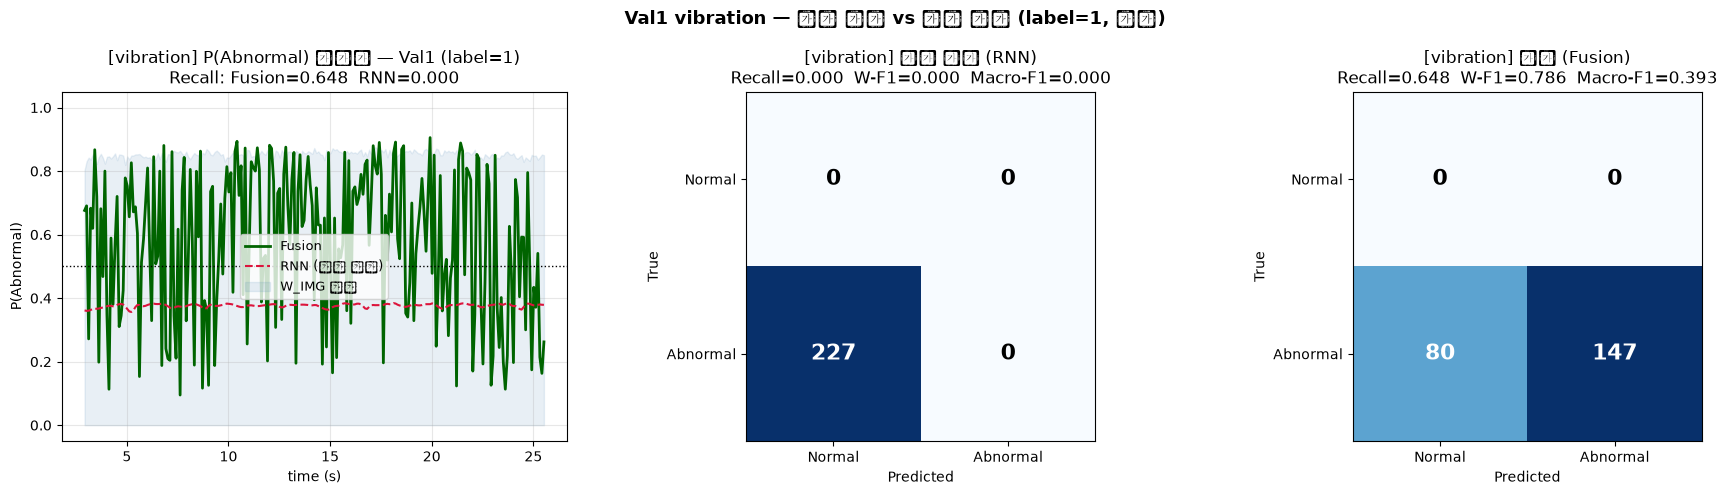

In [26]:
# 시각화 — 확률 시계열 + 혼동행렬 2개 (센서 단독 / 융합)
nt = NOISE_TYPES[0]   # vibration
df = results[nt]
y  = df['label'].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 확률 시계열 ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(df['time_sec'], df['p_final'],  color='darkgreen', lw=2,   label='Fusion')
ax.plot(df['time_sec'], df['p_sensor'], color='crimson',   lw=1.5,
        linestyle='--', label='RNN (센서 단독)')
ax.fill_between(df['time_sec'], df['w_img'], alpha=0.12,
                color='steelblue', label='W_IMG 비율')
ax.axhline(THRESHOLD, color='k', linestyle=':', lw=1)
ax.set_title(f'[{nt}] P(Abnormal) 시계열 — Val1 (label=1)\n'
             f'Recall: Fusion={summary_df.loc[nt,"recall_pred_fusion"]:.3f}  '
             f'RNN={summary_df.loc[nt,"recall_pred_sensor"]:.3f}')
ax.set_xlabel('time (s)'); ax.set_ylabel('P(Abnormal)')
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── 혼동행렬: 센서 단독(RNN) ──────────────────────────────────────
for ax, col, title_prefix in [
    (axes[1], 'pred_sensor', '센서 단독 (RNN)'),
    (axes[2], 'pred_fusion', '융합 (Fusion)'),
]:
    yp  = df[col].values
    cm  = confusion_matrix(y, yp, labels=[0, 1])
    rec = summary_df.loc[nt, f'recall_{col}']
    wf1 = summary_df.loc[nt, f'wf1_{col}']
    mf1 = summary_df.loc[nt, f'mf1_{col}']

    ax.imshow(cm, cmap='Blues')
    ax.set(xticks=[0, 1], yticks=[0, 1],
           xticklabels=['Normal', 'Abnormal'],
           yticklabels=['Normal', 'Abnormal'],
           xlabel='Predicted', ylabel='True',
           title=f'[{nt}] {title_prefix}\n'
                 f'Recall={rec:.3f}  W-F1={wf1:.3f}  Macro-F1={mf1:.3f}')
    th = cm.max() / 2 if cm.max() > 0 else 1
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > th else 'black',
                fontsize=16, fontweight='bold')

plt.suptitle('Val1 vibration — 센서 단독 vs 융합 비교 (label=1, 이상)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'fusion_val1_vibration_eval.png'), dpi=150)
plt.show()

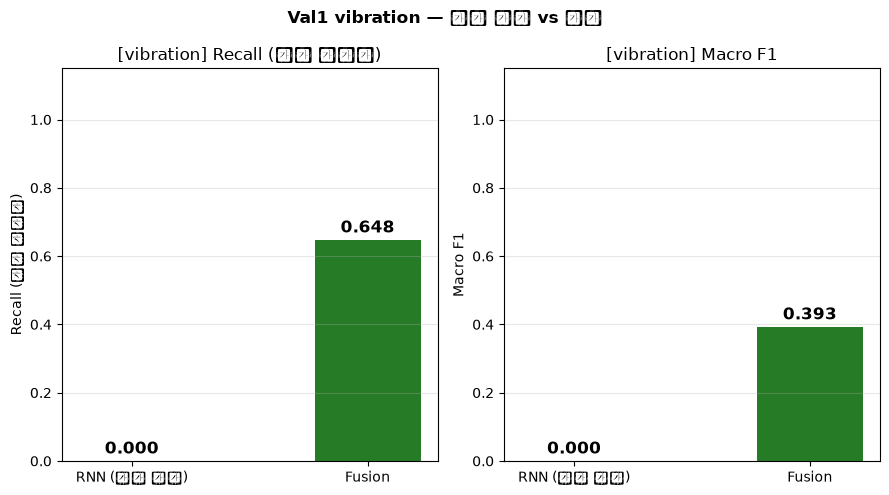


=== 최종 요약 ===
              n  w_img_mean  w_sen_mean  recall_pred_sensor  recall_pred_fusion  mf1_pred_sensor  mf1_pred_fusion
noise_type                                                                                                       
vibration   227      0.8519      0.1481                 0.0              0.6476              0.0            0.393


In [27]:
# Recall / Macro F1 비교 막대 그래프 (센서 단독 vs 융합)
nt   = NOISE_TYPES[0]
x    = np.arange(2)   # [RNN, Fusion]
fig, axes = plt.subplots(1, 2, figsize=(9, 5))

for ax, metric, ylabel in [
    (axes[0], 'recall', 'Recall (이상 검출률)'),
    (axes[1], 'mf1',    'Macro F1'),
]:
    vals   = [summary_df.loc[nt, f'{metric}_pred_sensor'],
              summary_df.loc[nt, f'{metric}_pred_fusion']]
    colors = ['crimson', 'darkgreen']
    labels = ['RNN (센서 단독)', 'Fusion']
    bars   = ax.bar(labels, vals, color=colors, alpha=0.85, width=0.45)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom',
                fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(ylabel)
    ax.set_title(f'[{nt}] {ylabel}')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Val1 vibration — 센서 단독 vs 융합', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(BASE_DIR / 'fusion_val1_vibration_compare.png'), dpi=150)
plt.show()

print('\n=== 최종 요약 ===')
print(summary_df[['n','w_img_mean','w_sen_mean',
                   'recall_pred_sensor','recall_pred_fusion',
                   'mf1_pred_sensor','mf1_pred_fusion']].to_string())